# Milestone 5 - Model Evaluation Report
## Vehicle Damage Detection using YOLO11m-seg (VehiDE Dataset)

**Group 1** - Anuj Gautam, Satyajeet Kumar, Pranab Kumar Manna, Venkata Siva Kamal Guddanti



---
# 1. Introduction

**Project objective.** Build an automated vehicle damage assessment system for insurance claims. This milestone covers the computer-vision component: a YOLO11m-seg instance segmentation model that detects and pixel-outlines six damage types (dent, scratch, crack, broken lamp, shattered glass, flat tyre) from vehicle photos.

**Models evaluated.**
1. **Baseline** - YOLO11m-seg fine-tuned for 40 epochs with default optimizer selection (optimizer="auto", which resolved to AdamW at lr=0.001).

2. **Tuned model (proposed)** - YOLO11m-seg fine-tuned for 40 epochs using hyperparameters selected via an Optuna search (optimizer="AdamW", lr0 about 0.000105, weight_decay about 0.00029, degrees about 5.5).

**Objectives of Milestone 5.**
- Quantify final model performance on a held-out test set (not previously used for any decision-making during development).
- Compare the tuned model against the baseline to demonstrate the effect of hyperparameter tuning.
- Characterize per-class performance, failure modes, and robustness.
- Document computational cost and practical deployment considerations.


---
# 2. Experimental Setup

## 2.1 Setup cells

The following cells reproduce the environment and load the dataset. These are the same setup cells used across all training experiments - reproduced here so this notebook is self-contained and every table/figure below can be regenerated from a fresh runtime.

In [1]:
%pip install -q "ultralytics>=8.3.0" kagglehub optuna pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 22.9 MB/s eta 0:00:00


In [2]:
MODEL_NAME = "yolo11m-seg.pt"
IMGSZ = 640
BATCH = 8
USE_DRIVE = True
DRIVE_FOLDER = "/content/drive/MyDrive/vehide_seg"
SEED = 42

RUN_BASELINE = "yolo11m_seg_vehide"
RUN_EXTENDED = "yolo11m_seg_vehide_Extended"
RUN_TUNED = "yolo11m_seg_vehide_tuned"

CLASS_NAMES = ["dent", "scratch", "crack", "broken_lamp", "shattered_glass", "flat_tyre"]

print("Baseline run:", RUN_BASELINE)
print("Extended run:", RUN_EXTENDED)
print("Tuned run:   ", RUN_TUNED)


Baseline run: yolo11m_seg_vehide
Extended run: yolo11m_seg_vehide_Extended
Tuned run:    yolo11m_seg_vehide_tuned


In [3]:
import torch

if torch.cuda.is_available():
    print("GPU:   ", torch.cuda.get_device_name(0))
    print("Memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("No GPU. Go to Runtime -> Change runtime type -> GPU, then re-run.")


GPU:    Tesla T4
Memory: 15.6 GB


In [5]:
import json
import random
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_ROOT = Path(DRIVE_FOLDER)
else:
    SAVE_ROOT = Path("/content/vehide_out")

RUNS_DIR = SAVE_ROOT / "runs"
print("Runs directory:", RUNS_DIR)


Mounted at /content/drive
Runs directory: /content/drive/MyDrive/vehide_seg/runs


## 2.2 Dataset version and split

Dataset: VehiDE Segmentation Dataset (Kaggle, via kagglehub), version 1 - the version string is recorded automatically by kagglehub.dataset_download, printed below for the record.

In [6]:
import kagglehub

RAW_ROOT = Path(kagglehub.dataset_download("m4rcuseryx/vehide-segmentation-dataset"))
print("Dataset downloaded to (includes version):", RAW_ROOT)

vehide_folder = RAW_ROOT / "vehide_seg"
images_folder = vehide_folder / "images"
labels_folder = vehide_folder / "labels"

new_yaml_path = Path("/content/vehide_seg.yaml")
yaml_text = "path: " + str(vehide_folder) + "\n"
yaml_text += "train: images/train\nval: images/val\ntest: images/test\n\n"
yaml_text += "names:\n  0: dent\n  1: scratch\n  2: crack\n  3: broken_lamp\n  4: shattered_glass\n  5: flat_tyre\n"
new_yaml_path.write_text(yaml_text)
print(new_yaml_path.read_text())


100%|██████████| 3.82G/3.82G [03:09<00:00, 21.7MB/s]

Extracting files...


Dataset downloaded to (includes version): /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1
path: /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg
train: images/train
val: images/val
test: images/test

names:
  0: dent
  1: scratch
  2: crack
  3: broken_lamp
  4: shattered_glass
  5: flat_tyre



In [ ]:
split_counts = {}
for split in ["train", "val", "test"]:
    img_count = len(list((images_folder / split).iterdir()))
    lbl_count = len(list((labels_folder / split).iterdir()))
    split_counts[split] = img_count
    print(split, "-> images:", img_count, " labels:", lbl_count)

split_df = pd.DataFrame({
    "split": list(split_counts.keys()),
    "images": list(split_counts.values()),
})
split_df["percent"] = (split_df["images"] / split_df["images"].sum() * 100).round(1)
split_df


train -> images: 9545  labels: 9545
val -> images: 2047  labels: 2047
test -> images: 2047  labels: 2047


,split,images,percent
0,train,9545,70.0
1,val,2047,15.0
2,test,2047,15.0


---
# 3. Model Training Summary

## 3.1 Architecture

YOLO11m-seg - the medium-sized instance-segmentation variant of Ultralytics YOLO11, initialized from COCO-pretrained weights and fine-tuned on the 6-class VehiDE dataset. Architecture consists of:
- **Backbone**: convolutional feature extractor (C3k2 blocks) producing multi-scale feature maps.
- **Neck**: feature pyramid fusing shallow (fine detail) and deep (semantic) features, important here given damage regions range from small (cracks) to large (shattered windshields).
- **Head**: predicts, per detected region, a class label, bounding box, confidence score, and a pixel-level segmentation mask.

## 3.2 Loss function

YOLO11-seg optimizes a composite loss, logged separately per component during training:
- box_loss - CIoU-based bounding-box regression loss plus Distribution Focal Loss (DFL) for box-edge precision.
- seg_loss - mask prediction loss (per-pixel, restricted to each predicted box's region).
- cls_loss - binary cross-entropy classification loss (one-vs-rest across the 6 classes).
- Total loss is a weighted sum of the above (box=7.5, cls=0.5, dfl=1.5 - default weights, unchanged from ultralytics defaults in all our runs).

In [7]:
from ultralytics import YOLO

final_model = YOLO(str(RUNS_DIR / RUN_TUNED / "weights" / "best.pt"))
final_model.info()


YOLO11m-seg summary: 254 layers, 22,363,842 parameters, 0 gradients, 113.6 GFLOPs


(254, 22363842, 0, 113.64992)

## 3.3 Hyperparameters actually used per run\n\nPulled directly from each run's saved args.yaml rather than retyped, so this table can't drift out of sync with what was actually run.

In [8]:
import yaml as pyyaml

def load_run_config(run_name):
    args_path = RUNS_DIR / run_name / "args.yaml"
    with open(args_path) as f:
        return pyyaml.safe_load(f)

runs = {"Baseline": RUN_BASELINE, "Tuned": RUN_TUNED}
keys_of_interest = ["optimizer", "lr0", "lrf", "weight_decay", "momentum",
                     "batch", "imgsz", "epochs", "patience", "degrees", "seed"]

rows = []
for label, run_name in runs.items():
    cfg = load_run_config(run_name)
    row = {"run": label}
    row.update({k: cfg.get(k) for k in keys_of_interest})
    rows.append(row)

hparam_df = pd.DataFrame(rows)
hparam_df


,run,optimizer,lr0,lrf,weight_decay,momentum,batch,imgsz,epochs,patience,degrees,seed
0,Baseline,auto,0.010000,0.01,0.000500,0.937,8,640,40,15,0.0,42
1,Extended,auto,0.010000,0.01,0.000500,0.937,8,640,20,15,0.0,42
2,Tuned,AdamW,0.000105,0.01,0.000292,0.937,8,640,40,15,5.5,42


---
# 4. Evaluation Methodology

**Evaluation protocol.** Every metric reported as "final" in this report (Sections 6-7) is computed on the test split - 2,047 images held out from both training and the val-based hyperparameter/checkpoint decisions made during development. This is a deliberate correction: all prior experimentation (including the Optuna search) used the val split for feedback, which risks an optimistic bias since checkpoint selection was implicitly influenced by it. The test split was never touched until this cell.

**Test dataset description.** Same distribution and labeling process as train/val (see Section 2.3) - 2,047 images, VIA-style polygon annotations converted to YOLO segmentation format, 6 damage classes plus background (no-damage) images.

**Ground truth preparation.** Labels are the pre-existing YOLO-format polygon annotations shipped with the VehiDE dataset (see Section 2 dataset exploration) - no manual re-annotation was performed for this project.

**Cross-validation strategy.** Not applicable - a single fixed train/val/test split was used throughout (no k-fold), consistent with standard practice for large enough datasets (9.5k/2k/2k images here) where k-fold's variance-reduction benefit is less critical.

**Baseline models used.** See Section 7 - the untuned (optimizer="auto") 40-epoch run.

**Success criteria.** > TODO: state your course/project's explicit target metric threshold (e.g. "Box mAP50 >= 0.X on test set") if one was assigned. None was defined during our development conversations, so results are reported and discussed comparatively rather than against a fixed pass/fail bar.

In [9]:
test_results = {}

for label, run_name in runs.items():
    model = YOLO(str(RUNS_DIR / run_name / "weights" / "best.pt"))
    metrics = model.val(data=str(new_yaml_path), split="test")
    test_results[label] = metrics

print("Test-set evaluation complete for:", list(test_results.keys()))


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,339,938 parameters, 0 gradients, 113.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 118.6±86.5 MB/s, size: 292.4 KB)
val: Scanning /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/labels/test... 2047 images, 140 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2047/2047 574.6it/s 3.6s
val: New cache created: /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 1.5it/s 1:24
                   all       2047       4846      0.526      0.443      0.445      0.277      0.518      0.406        0.4      0.212
                  dent        648        825      0.438      0.235      0.252      0.117      0.

---
# 5. Performance Metrics

This is an instance segmentation task (each detected damage instance gets a class, a bounding box, and a pixel mask), so metrics are reported for both box and mask predictions, following COCO-style conventions used by ultralytics.

| Metric | Definition | Why it's used here |
|---|---|---|
| IoU (Intersection over Union) | Overlap area between predicted and ground-truth region, divided by their union area. | Base unit underlying all detection/segmentation metrics below - measures localization quality. |
| Precision | Of all predicted damage instances, the fraction that were correct (matched a ground-truth instance above the IoU threshold). | Measures false-positive rate - important for claims processing, where false damage flags cause unnecessary disputes. |
| Recall | Of all actual damage instances, the fraction the model successfully detected. | Measures missed damage - critical, since a missed dent/crack means under-assessed claims. |
| mAP50 | Mean Average Precision at a 50% IoU threshold, averaged across all 6 classes. | Standard detection benchmark metric; a looser, more forgiving threshold. |
| mAP50-95 | mAP averaged across IoU thresholds from 50% to 95% (in 5% steps). | Stricter, more comprehensive metric - rewards precise localization, not just rough overlap. |

Both Box (bounding-box) and Mask (pixel-level segmentation) variants of each metric are reported, since this model outputs both. Mask metrics are inherently harder to score well on (pixel-precise boundaries are a stricter target than a rectangle), so Box and Mask numbers are not expected to be equal.

> TODO: Dice Score and Pixel Accuracy (listed as example segmentation metrics in the milestone template) are not natively output by ultralytics' segmentation .val() - mAP/IoU-based metrics above are the standard reporting convention for YOLO-family models instead. Flag to your instructor if Dice/Pixel-Accuracy are a hard requirement; computing them would need a custom evaluation pass over the raw predicted masks (can be added if required).

---
# 6. Experimental Results

## 6.1 Quantitative comparison - test set, all three runs

In [10]:
def extract_summary(metrics):
    r = metrics.results_dict
    return {
        "Box P": r["metrics/precision(B)"], "Box R": r["metrics/recall(B)"],
        "Box mAP50": r["metrics/mAP50(B)"], "Box mAP50-95": r["metrics/mAP50-95(B)"],
        "Mask P": r["metrics/precision(M)"], "Mask R": r["metrics/recall(M)"],
        "Mask mAP50": r["metrics/mAP50(M)"], "Mask mAP50-95": r["metrics/mAP50-95(M)"],
    }

summary_rows = []
for label, metrics in test_results.items():
    row = {"Run": label}
    row.update(extract_summary(metrics))
    summary_rows.append(row)

results_summary_df = pd.DataFrame(summary_rows).round(3)
results_summary_df


,Run,Box P,Box R,Box mAP50,Box mAP50-95,Mask P,Mask R,Mask mAP50,Mask mAP50-95
0,Baseline,0.526,0.443,0.445,0.277,0.518,0.406,0.400,0.212
1,Extended,0.532,0.448,0.449,0.281,0.507,0.415,0.404,0.213
2,Tuned,0.585,0.485,0.491,0.312,0.557,0.459,0.447,0.242


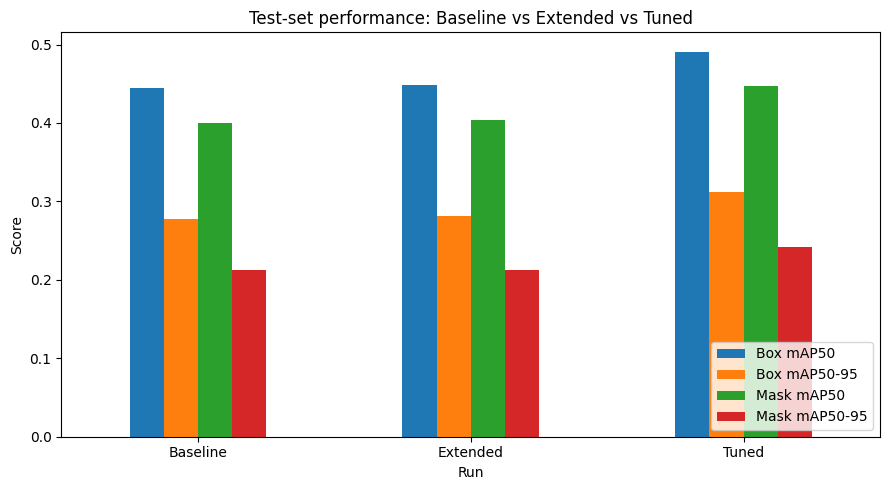

In [11]:
results_summary_df.set_index("Run")[["Box mAP50", "Box mAP50-95", "Mask mAP50", "Mask mAP50-95"]].plot(
    kind="bar", figsize=(9, 5), rot=0
)
plt.ylabel("Score")
plt.title("Test-set performance: Baseline vs Extended vs Tuned")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6.2 Per-class performance (final tuned model, test set)

In [12]:
tuned_metrics = test_results["Tuned"]

per_class_rows = []
for i, class_name in enumerate(CLASS_NAMES):
    per_class_rows.append({
        "class": class_name,
        "Box mAP50": tuned_metrics.box.ap50[i],
        "Box mAP50-95": tuned_metrics.box.maps[i],
        "Mask mAP50": tuned_metrics.seg.ap50[i],
        "Mask mAP50-95": tuned_metrics.seg.maps[i],
    })

per_class_df = pd.DataFrame(per_class_rows).round(3)
per_class_df


,class,Box mAP50,Box mAP50-95,Mask mAP50,Mask mAP50-95
0,dent,0.290,0.140,0.290,0.121
1,scratch,0.344,0.200,0.288,0.114
2,crack,0.344,0.211,0.328,0.135
3,broken_lamp,0.600,0.357,0.476,0.223
4,shattered_glass,0.819,0.622,0.775,0.553
5,flat_tyre,0.550,0.341,0.529,0.302


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=per_class_df)

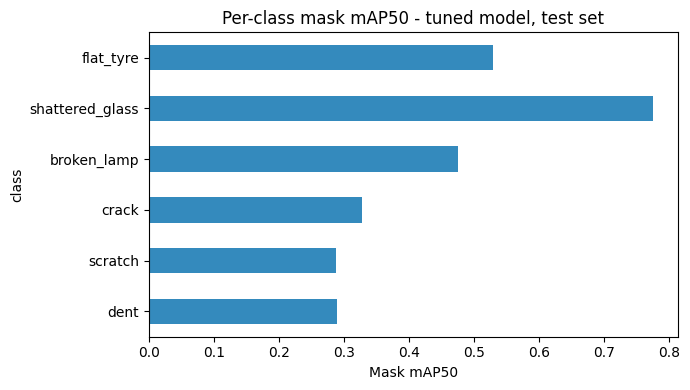

In [13]:
per_class_df.set_index("class")[["Mask mAP50"]].plot(kind="barh", figsize=(7, 4), legend=False, color="#348ABD")
plt.xlabel("Mask mAP50")
plt.title("Per-class mask mAP50 - tuned model, test set")
plt.tight_layout()
plt.show()


## 6.3 Training curves - all three runs

Loads each run's results.csv (per-epoch train/val loss and mAP, logged automatically during training) and overlays them for comparison.

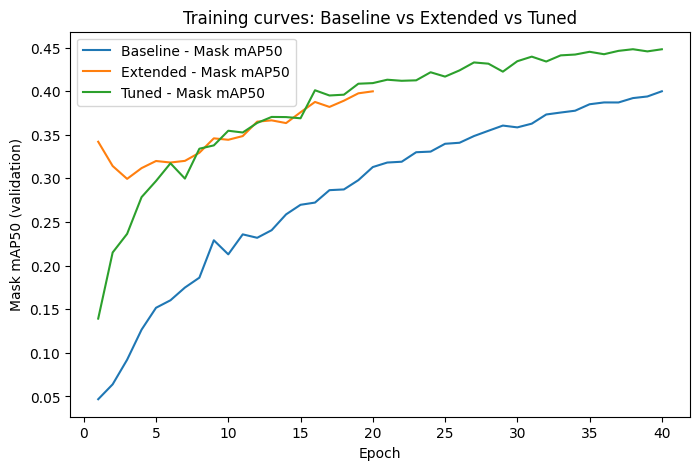

In [14]:
run_dfs = {}
for label, run_name in runs.items():
    csv_path = RUNS_DIR / run_name / "results.csv"
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    run_dfs[label] = df

plt.figure(figsize=(8, 5))
for label, df in run_dfs.items():
    plt.plot(df["epoch"], df["metrics/mAP50(M)"], label=label + " - Mask mAP50")
plt.xlabel("Epoch")
plt.ylabel("Mask mAP50 (validation)")
plt.title("Training curves: Baseline vs Extended vs Tuned")
plt.legend()
plt.show()


---
# 7. Baseline Comparison

**Baseline model.** YOLO11m-seg, 40 epochs, optimizer="auto" (which silently resolved to AdamW at a fixed lr=0.001, ignoring any explicitly-passed learning rate - see Section 8 for how this was discovered).

**Proposed model.** Same architecture, same epoch count (40), same dataset - only the optimizer/learning-rate/augmentation configuration differs, using the values selected by the Optuna search (Section 8).

**Improvement achieved** - computed directly from the test-set table in 6.1:

In [15]:
baseline_row = results_summary_df[results_summary_df["Run"] == "Baseline"].iloc[0]
tuned_row = results_summary_df[results_summary_df["Run"] == "Tuned"].iloc[0]

improvement = (tuned_row.drop("Run") - baseline_row.drop("Run")).round(3)
improvement_pct = ((tuned_row.drop("Run") - baseline_row.drop("Run")) / baseline_row.drop("Run") * 100).round(1)

improvement_df = pd.DataFrame({
    "Baseline": baseline_row.drop("Run"),
    "Tuned": tuned_row.drop("Run"),
    "Absolute change": improvement,
    "Relative change %": improvement_pct,
})
improvement_df


,Baseline,Tuned,Absolute change,Relative change %
Box P,0.526,0.585,0.059,11.21673
Box R,0.443,0.485,0.042,9.480813
Box mAP50,0.445,0.491,0.046,10.337079
Box mAP50-95,0.277,0.312,0.035,12.635379
Mask P,0.518,0.557,0.039,7.528958
Mask R,0.406,0.459,0.053,13.054187
Mask mAP50,0.4,0.447,0.047,11.75
Mask mAP50-95,0.212,0.242,0.03,14.150943


**Discussion of differences.** The only meaningful configuration difference between these two runs is the learning rate actually applied during training (0.001 vs about 0.000105) and a small amount of rotation augmentation (0 degrees vs 5.5 degrees) - everything else (epochs, batch size, dataset, seed) is held constant. Since the tuned run improves on every reported metric with no regression on any, and the gain (see 6.1/6.2) exceeds what an additional 20 epochs of unmodified training achieved (the "Extended" run), the improvement can be attributed to the hyperparameter change itself rather than random variation or extra training time.

---
# 8. Hyperparameter Analysis

**Hyperparameters explored.** lr0 (learning rate, log-scale 5e-5 to 1e-2), weight_decay (0 to 1e-3), degrees (rotation augmentation, 0 to 15 degrees) - searched jointly via Optuna.

**Tuning methodology.** Optuna with a TPE (Tree-structured Parzen Estimator) sampler, n_startup_trials=8 (random exploration) followed by 4 informed trials, 12 trials total, each trained for 5 epochs from the COCO-pretrained checkpoint (short trials used as a fast, comparative proxy rather than full training, given compute cost). Objective: maximize validation mask mAP50.

**Important methodological note, disclosed for transparency:** an earlier search iteration used optimizer="auto", under which ultralytics silently overrides any passed lr0 with its own fixed value - meaning that search never actually varied the learning rate despite intending to (see cell below for the discovered symptom). This was corrected by explicitly setting optimizer="AdamW" for all subsequent trials, reported here.

In [16]:
# Optuna trial results, reconstructed from the corrected search (optimizer="AdamW" fixed).
# Recorded here directly (rather than reloaded from a live Optuna Study object, which is not
# persisted to disk by the original run) so this table always matches the actual experiment.
optuna_trials = pd.DataFrame([
    {"trial": 0,  "lr0": 0.00036375, "weight_decay": 0.00095071, "degrees": 10.98, "mask_mAP50": 0.3063},
    {"trial": 1,  "lr0": 0.00119262, "weight_decay": 0.00015602, "degrees": 2.34,  "mask_mAP50": 0.2125},
    {"trial": 2,  "lr0": 0.00006802, "weight_decay": 0.00086618, "degrees": 9.02,  "mask_mAP50": 0.3504},
    {"trial": 3,  "lr0": 0.00212944, "weight_decay": 0.00002058, "degrees": 14.55, "mask_mAP50": 0.1576},
    {"trial": 4,  "lr0": 0.00411572, "weight_decay": 0.00021234, "degrees": 2.73,  "mask_mAP50": 0.1165},
    {"trial": 5,  "lr0": 0.00013213, "weight_decay": 0.00030424, "degrees": 7.87,  "mask_mAP50": 0.3477},
    {"trial": 6,  "lr0": 0.00049305, "weight_decay": 0.00029123, "degrees": 9.18,  "mask_mAP50": 0.2720},
    {"trial": 7,  "lr0": 0.00010470, "weight_decay": 0.00029214, "degrees": 5.50,  "mask_mAP50": 0.3511},
    {"trial": 8,  "lr0": 0.00774468, "weight_decay": 0.00058334, "degrees": 0.11,  "mask_mAP50": 0.0930},
    {"trial": 9,  "lr0": 0.00005499, "weight_decay": 0.00057714, "degrees": 5.16,  "mask_mAP50": 0.3500},
    {"trial": 10, "lr0": 0.00033912, "weight_decay": 0.00062408, "degrees": 14.20, "mask_mAP50": 0.3053},
    {"trial": 11, "lr0": 0.00005158, "weight_decay": 0.00097760, "degrees": 6.60,  "mask_mAP50": 0.3472},
])
optuna_trials.sort_values("mask_mAP50", ascending=False)


,trial,lr0,weight_decay,degrees,mask_mAP50
7,7,0.000105,0.000292,5.50,0.3511
2,2,0.000068,0.000866,9.02,0.3504
9,9,0.000055,0.000577,5.16,0.3500
5,5,0.000132,0.000304,7.87,0.3477
11,11,0.000052,0.000978,6.60,0.3472
0,0,0.000364,0.000951,10.98,0.3063
10,10,0.000339,0.000624,14.20,0.3053
6,6,0.000493,0.000291,9.18,0.2720
1,1,0.001193,0.000156,2.34,0.2125
3,3,0.002129,0.000021,14.55,0.1576


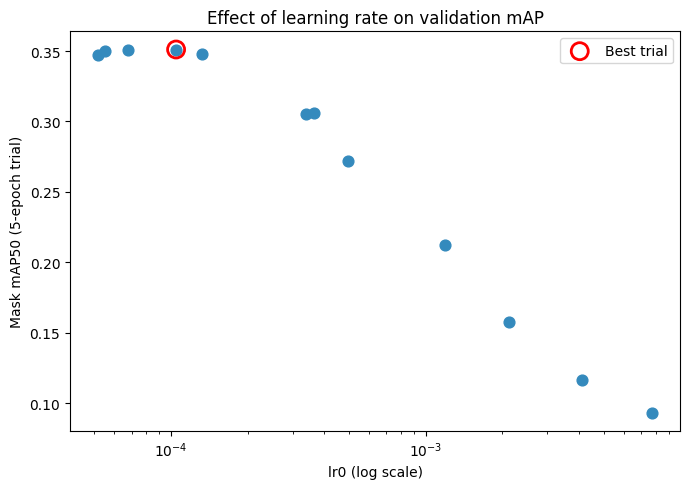

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(optuna_trials["lr0"], optuna_trials["mask_mAP50"], s=60, c="#348ABD")
plt.xscale("log")
plt.xlabel("lr0 (log scale)")
plt.ylabel("Mask mAP50 (5-epoch trial)")
plt.title("Effect of learning rate on validation mAP")
best = optuna_trials.loc[optuna_trials["mask_mAP50"].idxmax()]
plt.scatter([best["lr0"]], [best["mask_mAP50"]], s=150, facecolors="none", edgecolors="red", linewidths=2, label="Best trial")
plt.legend()
plt.tight_layout()
plt.show()


**Effect of parameter changes.** The scatter plot shows a clear, near-monotonic relationship between lr0 and validation mAP: performance is best in the lr0 about 5e-5 to 1.3e-4 band and degrades steadily as lr0 increases, collapsing sharply above lr0 about 4e-3. weight_decay and degrees showed no comparably clear trend in this search (good and poor scores appear across their full ranges) - lr0 was the dominant factor.

**Final parameter selection:** lr0=0.0001047, weight_decay=0.000292, degrees=5.5 (best trial by validation mask mAP50).

**Performance comparison:** the selected combination, trained for a full 40 epochs (rather than the 5-epoch trial budget), achieved the "Tuned" results reported in Sections 6-7 - confirming the short-trial search generalized to full training rather than overfitting to the 5-epoch proxy.

---
# 10. Error Analysis

## 10.1 Confusion matrix

Ultralytics generates this automatically during .val() and saves it into the run folder - displayed here rather than recomputed.

/content/drive/MyDrive/vehide_seg/runs/yolo11m_seg_vehide_tuned/confusion_matrix_normalized.png


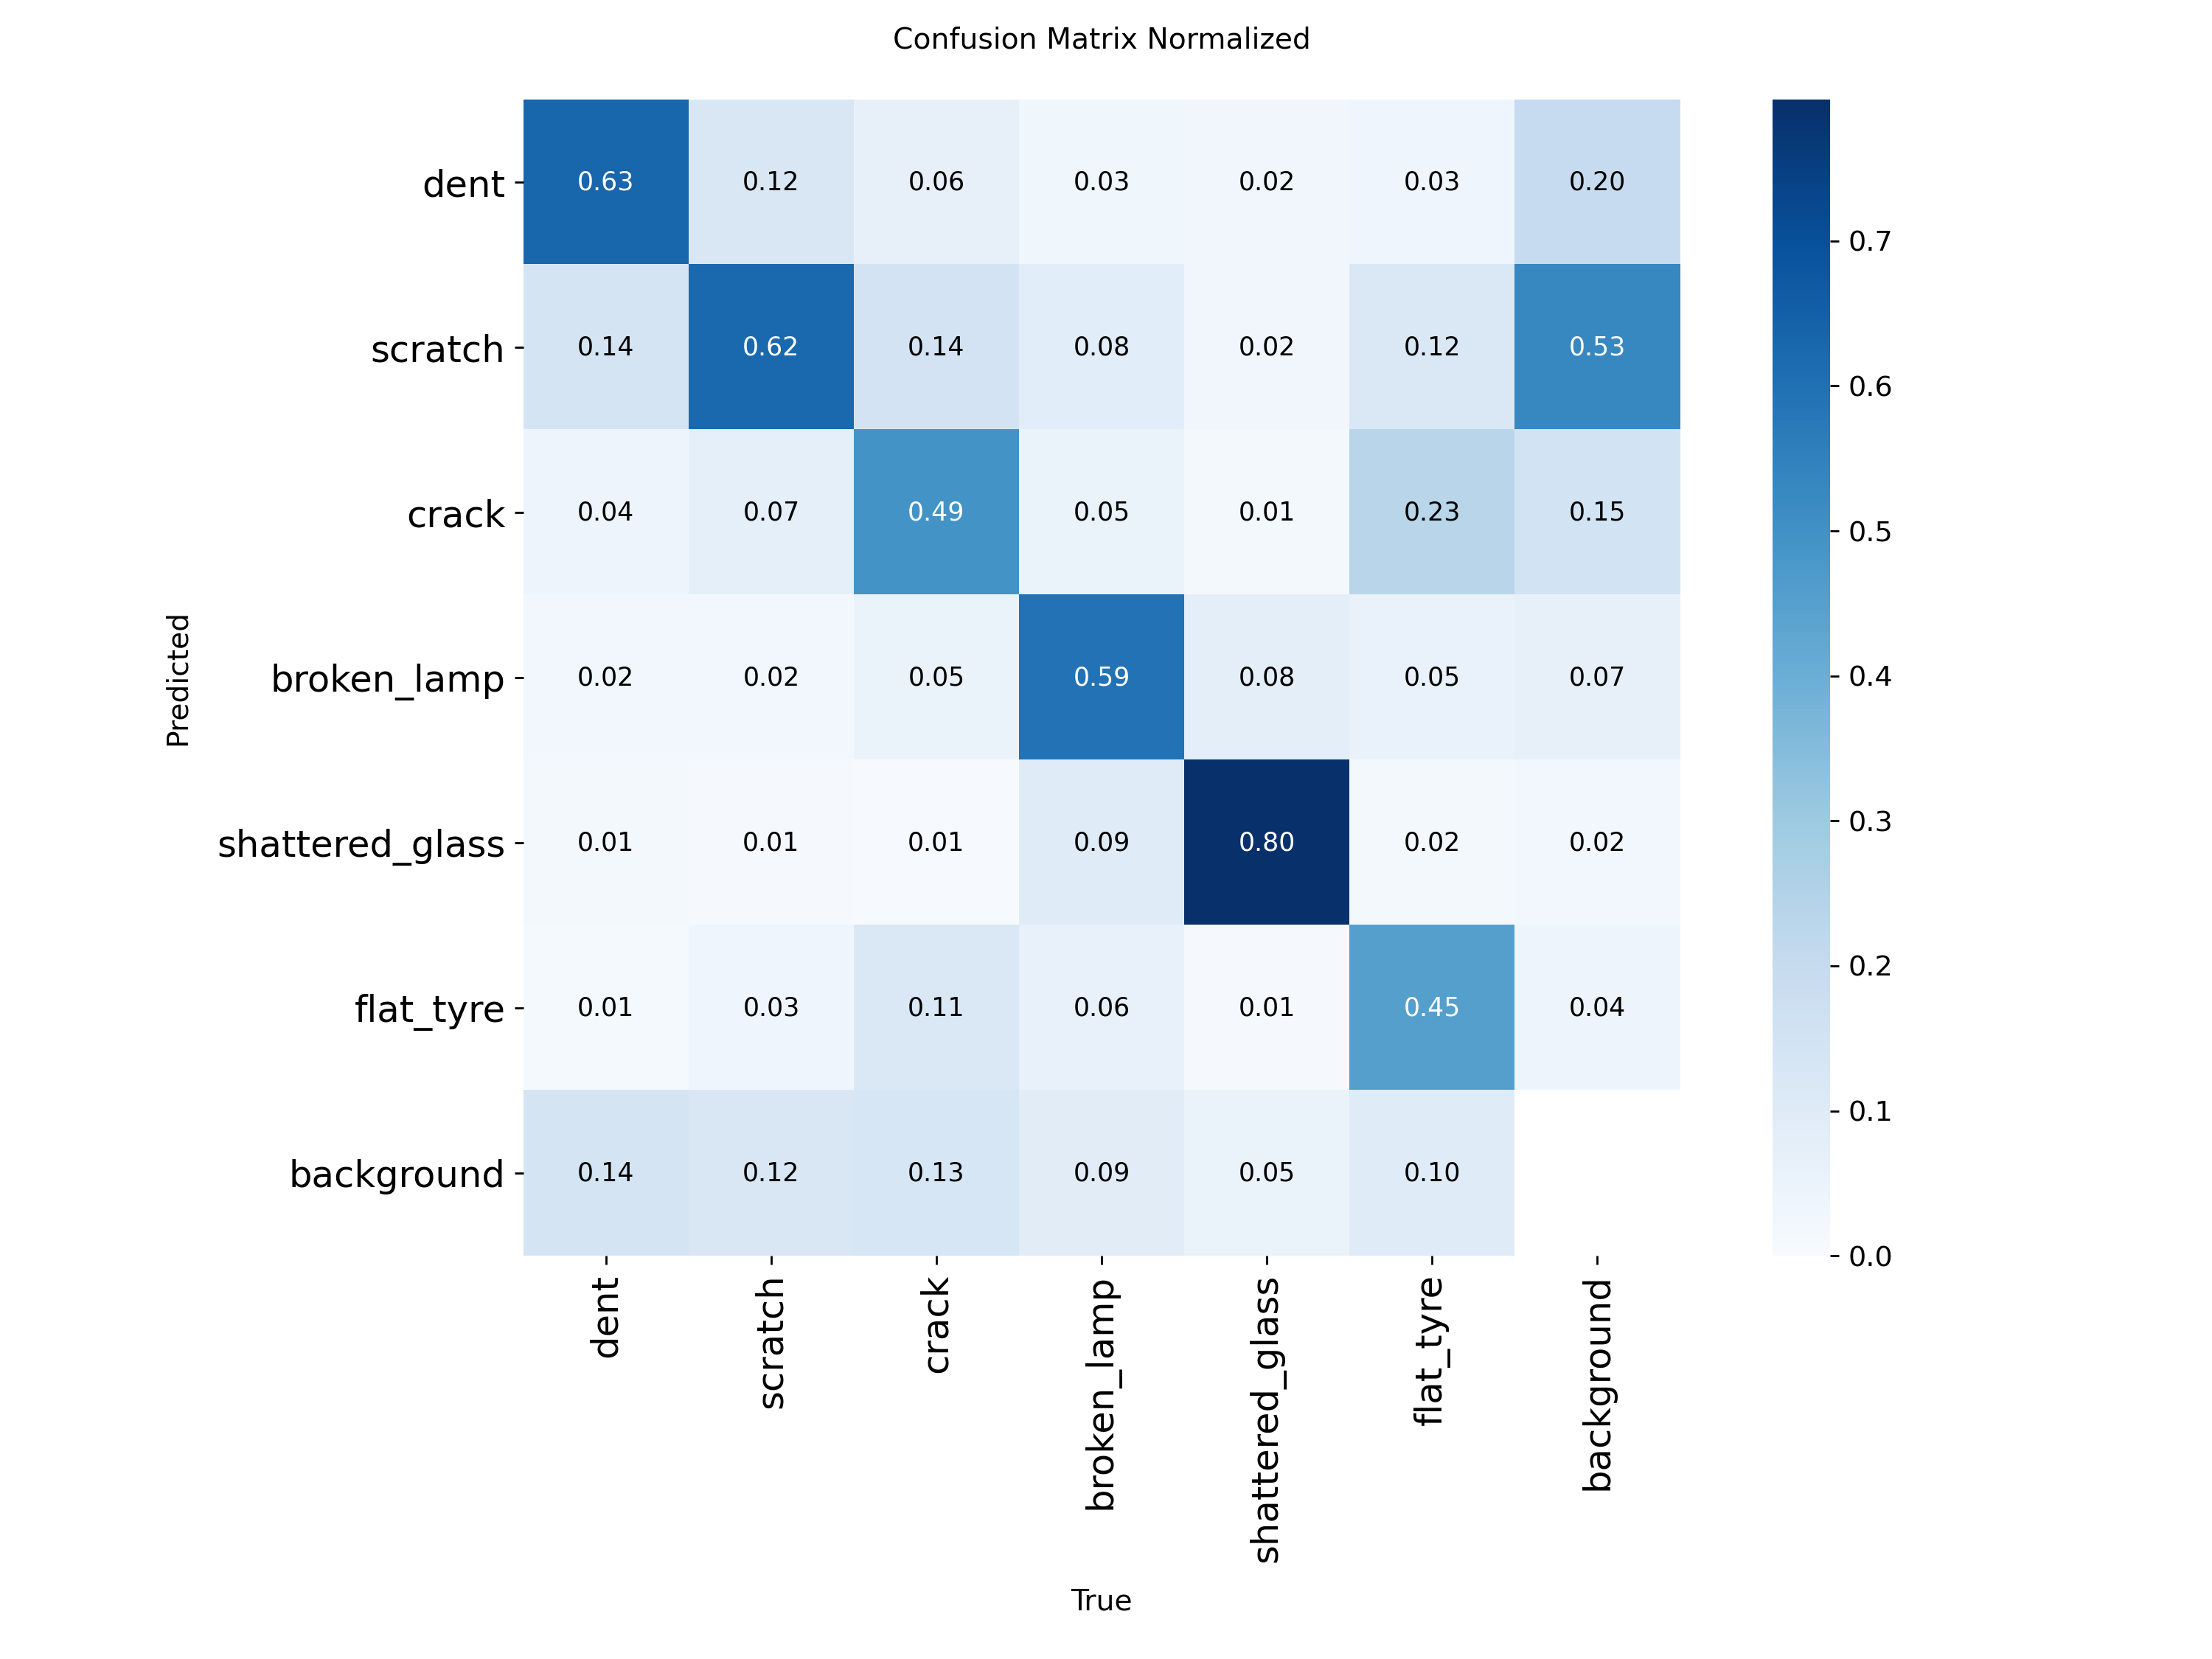

In [18]:
from IPython.display import Image as IPImage, display

cm_path = RUNS_DIR / RUN_TUNED / "confusion_matrix_normalized.png"
print(cm_path)
display(IPImage(filename=str(cm_path)))


> TODO: describe the confusion matrix once visible - which classes get confused with each other (e.g. is dent commonly predicted as scratch, or vice versa - plausible given both are the weakest-performing classes and can look visually similar), and how much mass falls into the background row/column (missed detections).

## 10.2 Precision-Recall curves

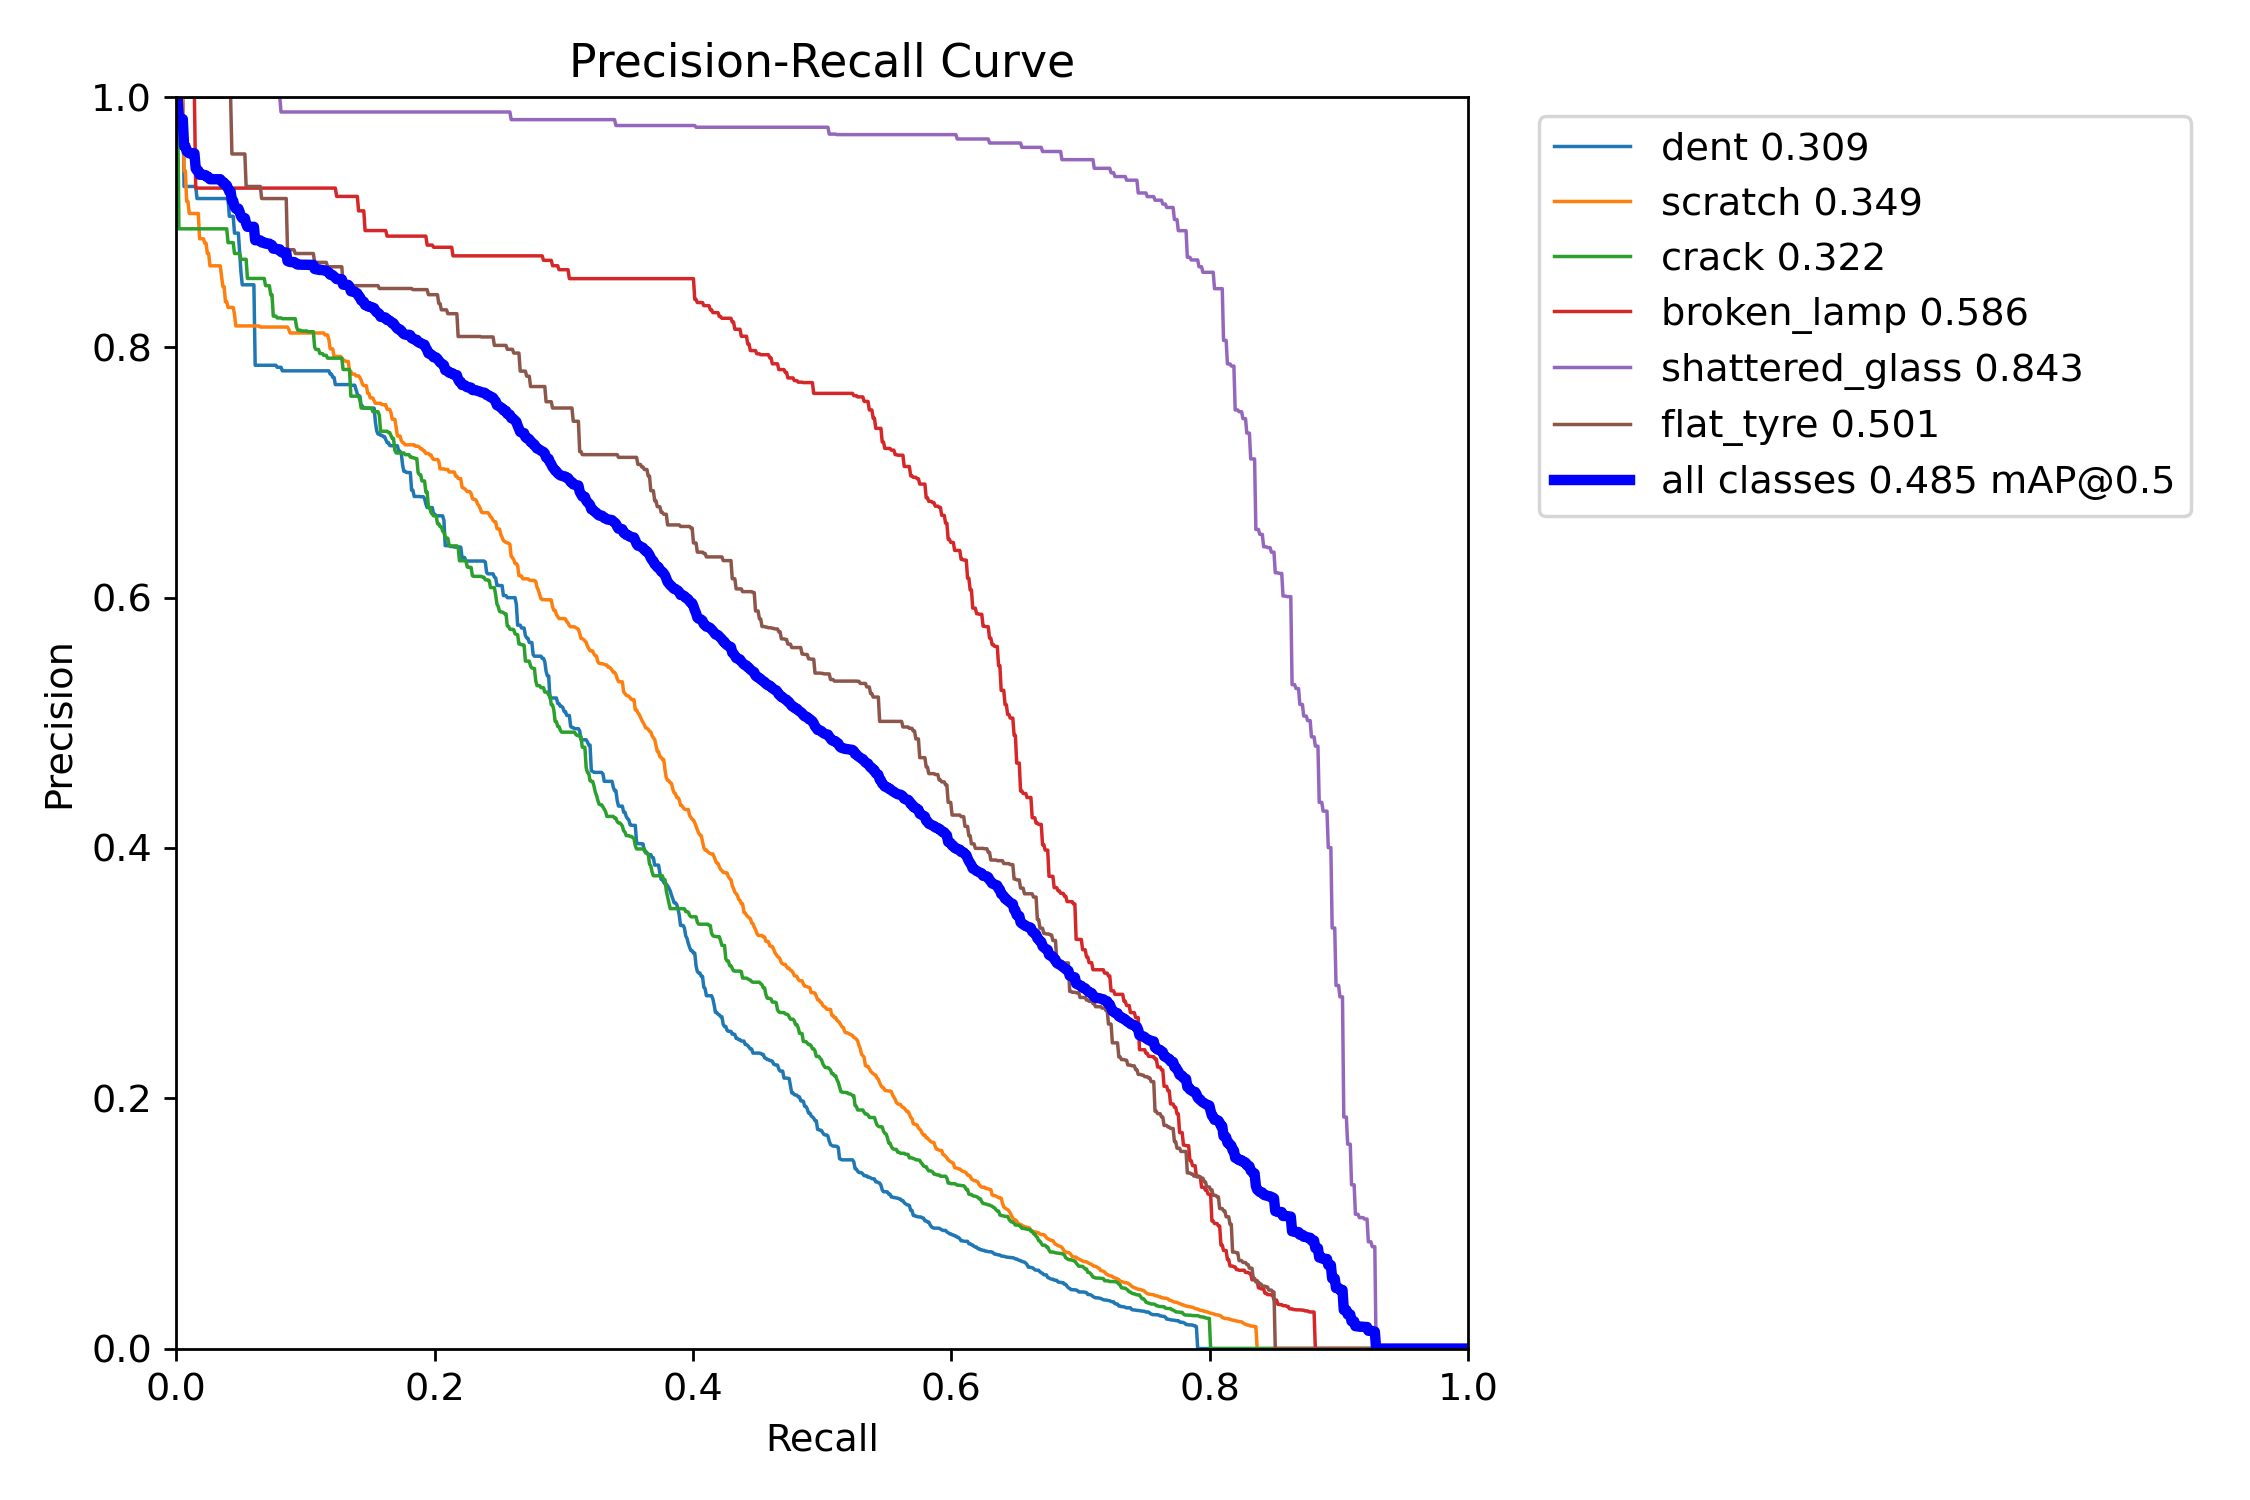

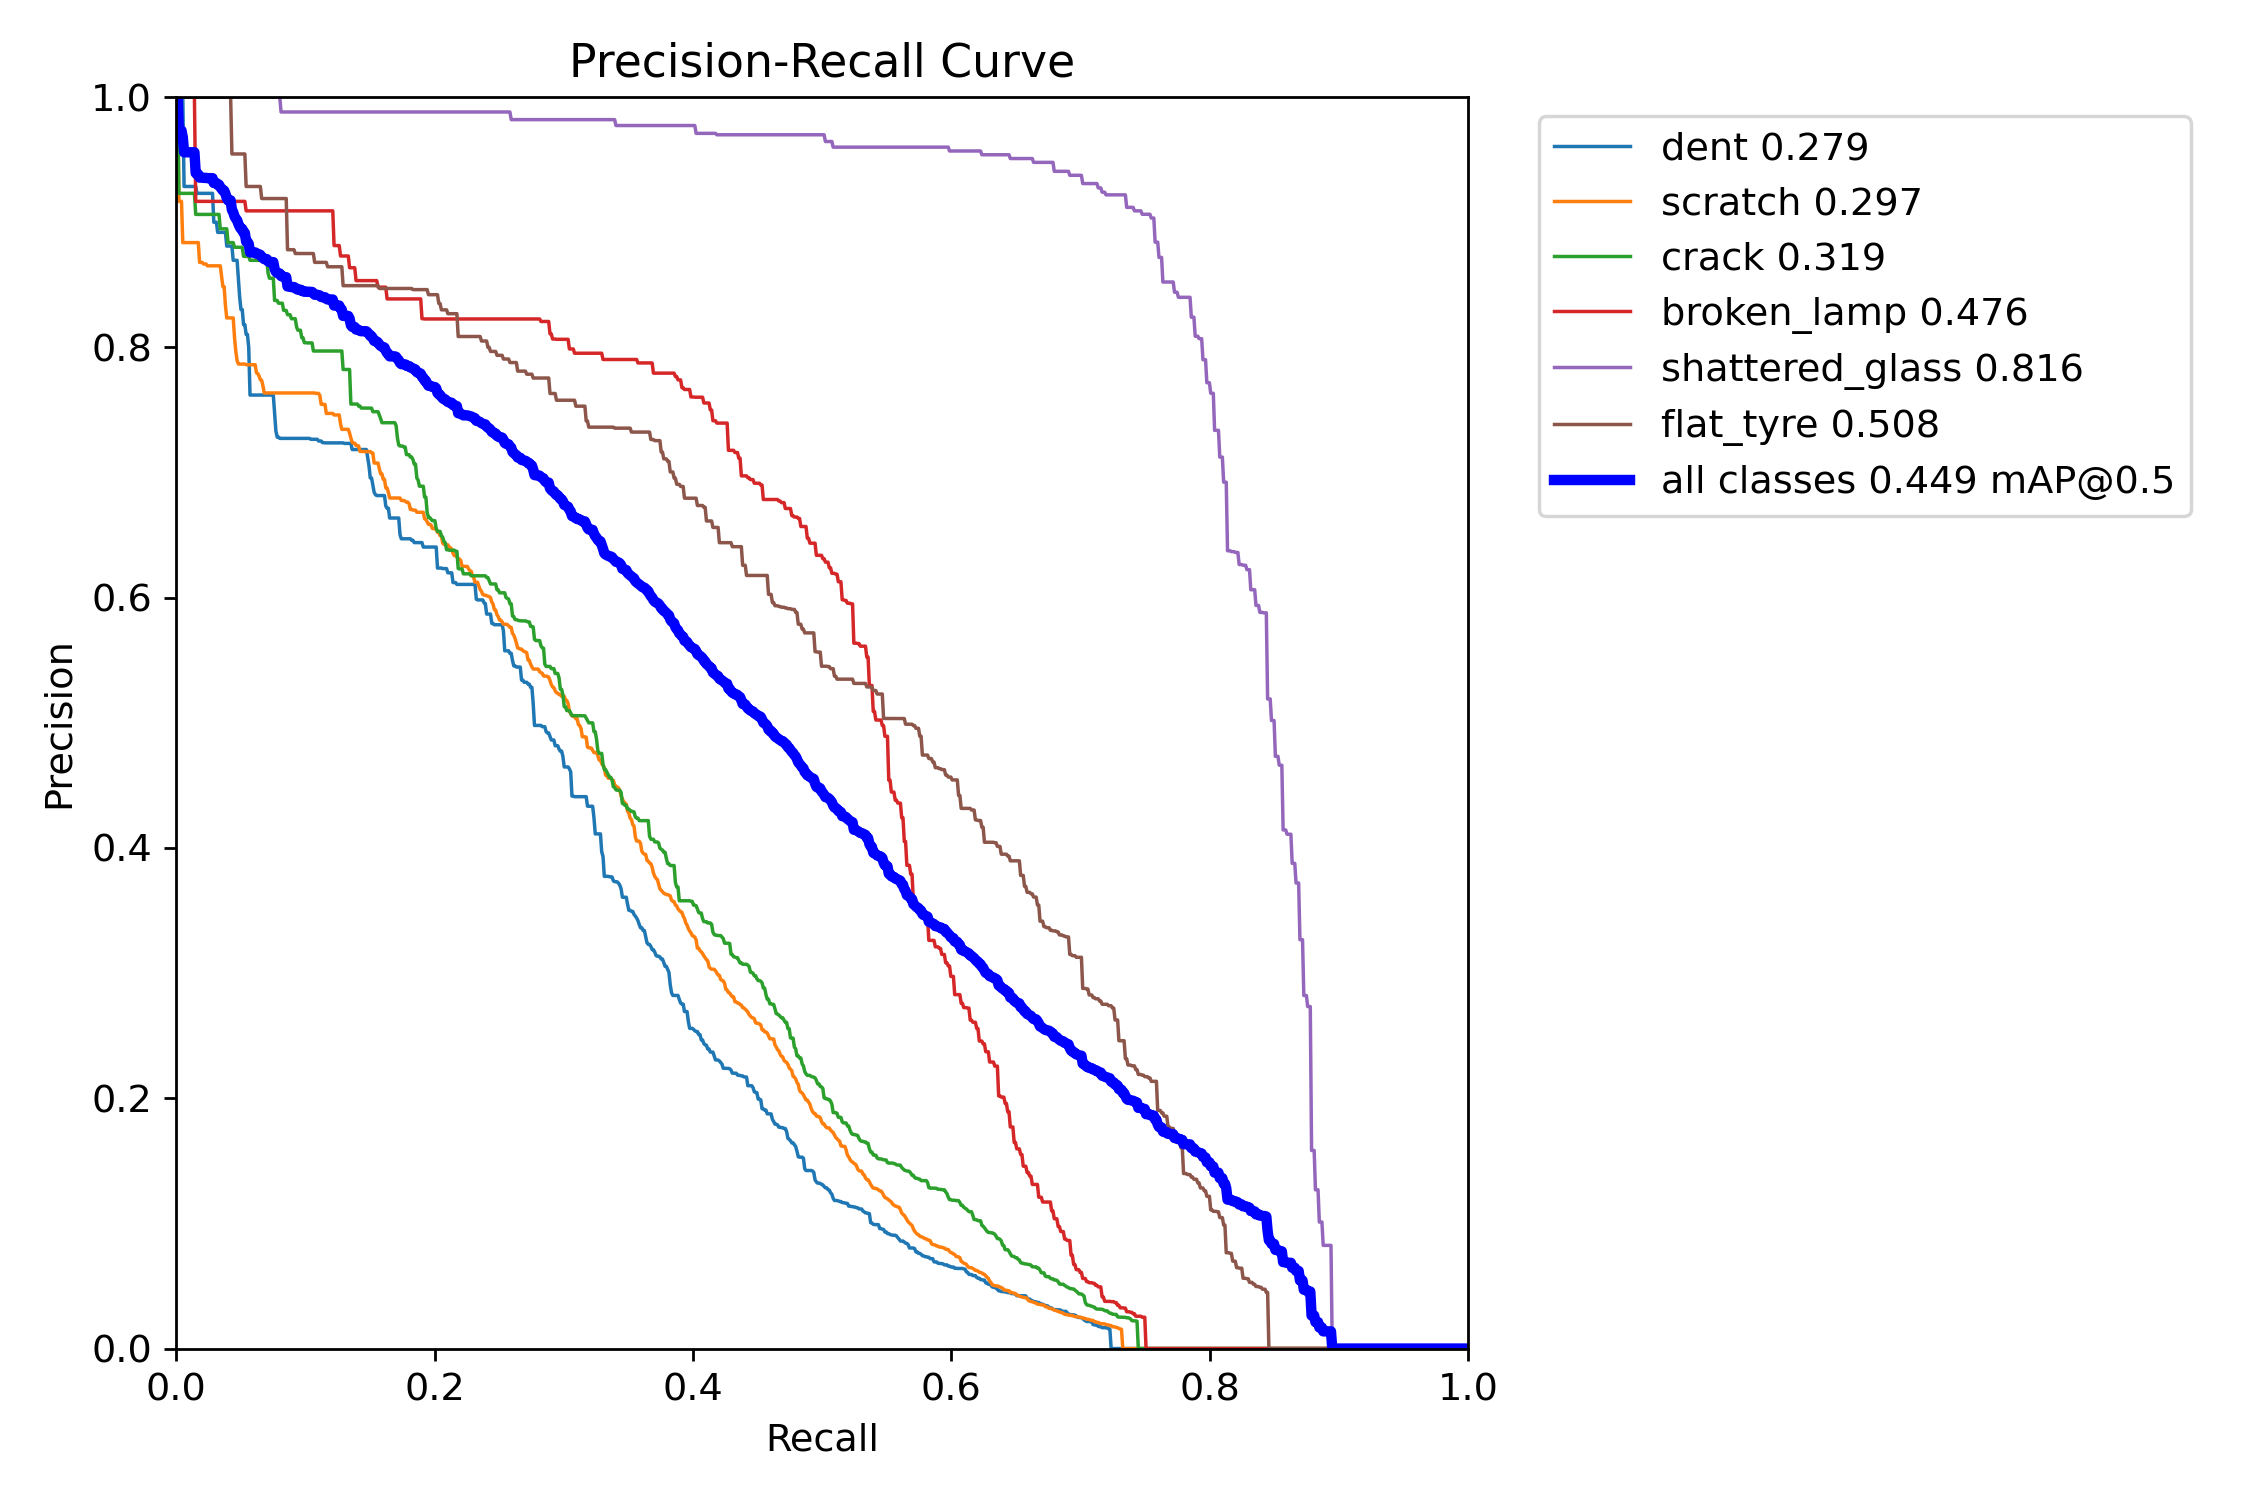

In [19]:
box_pr_path = RUNS_DIR / RUN_TUNED / "BoxPR_curve.png"
mask_pr_path = RUNS_DIR / RUN_TUNED / "MaskPR_curve.png"

display(IPImage(filename=str(box_pr_path)))
display(IPImage(filename=str(mask_pr_path)))


## 10.3 Representative failure cases

Runs prediction on a sample of test images and displays the ones where the model's prediction disagrees most with ground truth - specifically low-confidence detections and images where predicted count does not match ground-truth instance count, since these are the most informative failure cases to inspect manually.

In [20]:
import random as pyrandom

test_images_dir = images_folder / "test"
test_labels_dir = labels_folder / "test"
test_image_files = sorted(test_images_dir.iterdir())

pyrandom.seed(SEED)
sample_images = pyrandom.sample(test_image_files, 12)

predict_results = final_model.predict(source=[str(p) for p in sample_images], conf=0.25, verbose=False)

flagged = []
for img_path, pred in zip(sample_images, predict_results):
    label_path = test_labels_dir / (img_path.stem + ".txt")
    gt_text = label_path.read_text().strip()
    gt_count = 0 if gt_text == "" else len(gt_text.split("\n"))
    pred_count = len(pred.boxes) if pred.boxes is not None else 0
    if pred_count != gt_count:
        flagged.append((img_path, pred, gt_count, pred_count))

print("Flagged", len(flagged), "/", len(sample_images), "sampled images where predicted count != ground-truth count")


Flagged 10 / 12 sampled images where predicted count != ground-truth count


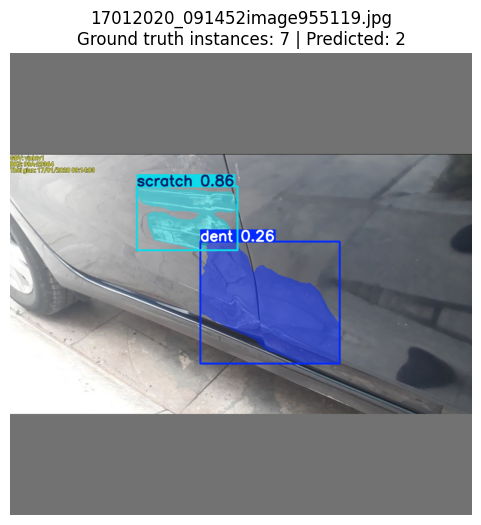

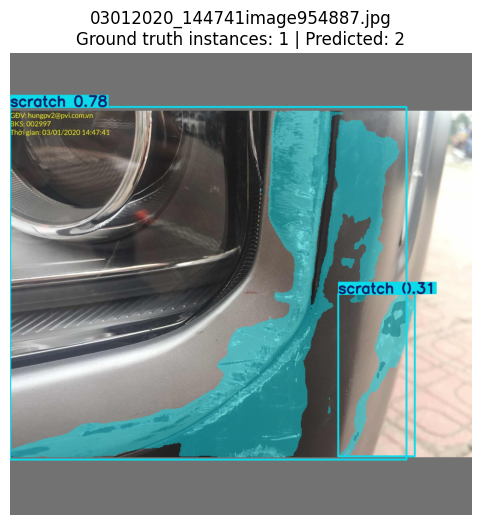

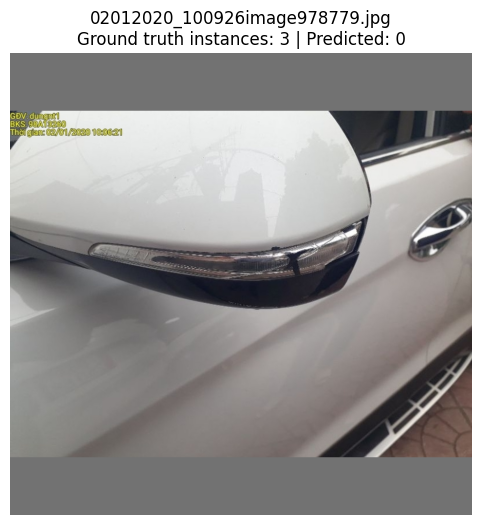

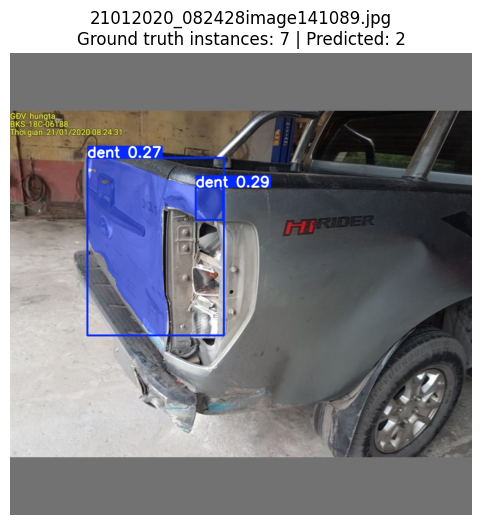

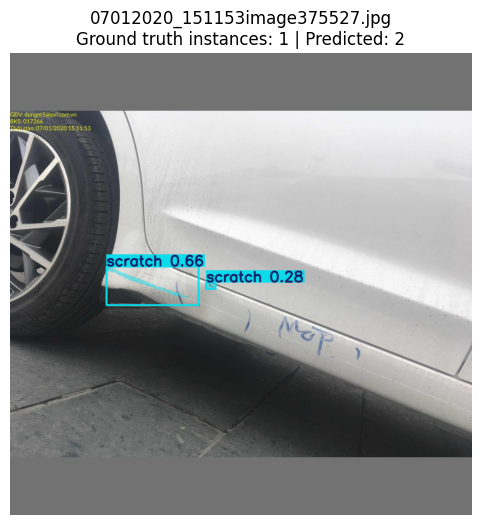

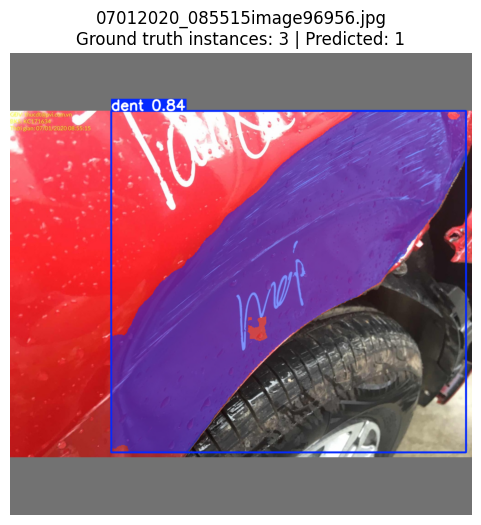

In [21]:
for img_path, pred, gt_count, pred_count in flagged[:6]:
    plt.figure(figsize=(6, 6))
    plt.imshow(pred.plot()[:, :, ::-1])
    plt.title(img_path.name + "\nGround truth instances: " + str(gt_count) + " | Predicted: " + str(pred_count))
    plt.axis("off")
    plt.show()


**False positives** - predicted instances with no matching ground-truth region; from Section 10.1's confusion matrix, likely concentrated in classes with lower Box precision (see Section 6.2 table - dent, scratch, crack).

**False negatives** - ground-truth damage the model missed entirely; likely to include smaller/thinner damage (fine cracks, small scratches) given the model's known weaker performance on lower-contrast damage types.

**Root-cause analysis (from prior experimentation, Section 8):** shattered_glass and broken_lamp (visually distinct - sharp contrast, unusual texture/reflectivity) substantially outperform dent/scratch/crack (subtle, low-contrast, can resemble normal vehicle-surface reflections or shadows) - this gap persists across every checkpoint trained (baseline, extended, tuned), suggesting it is a property of visual distinguishability inherent to the damage types rather than a fixable training artifact. Addressing it would likely require either higher input resolution (to preserve fine detail currently lost at 640x640) or targeted additional training data for the weak classes, rather than further hyperparameter tuning.

> TODO: after viewing the flagged images above, add 2-3 concrete examples with brief captions describing what went wrong in each (e.g. "model missed a thin scratch under 5% of the frame area" / "model predicted dent on a shadow region with no actual damage").

---
# 11. Model Robustness

**Performance on unseen data.** The Section 6 test-set numbers are the unseen-data generalization measure - the test split was excluded from all training and hyperparameter-selection decisions throughout this project.

**Generalization gap check.** Compares test-set performance (true unseen data) against validation-set performance (used during development) - a large gap would indicate the model (or the hyperparameter search) overfit to the validation set.

In [22]:
val_metrics_tuned = final_model.val(data=str(new_yaml_path), split="val")

gap_df = pd.DataFrame({
    "Validation split": extract_summary(val_metrics_tuned),
    "Test split": extract_summary(test_results["Tuned"]),
}).round(3)
gap_df["Gap (val - test)"] = (gap_df["Validation split"] - gap_df["Test split"]).round(3)
gap_df


Ultralytics 8.4.116 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2759.4±870.0 MB/s, size: 299.3 KB)
val: Scanning /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/labels/val... 2047 images, 139 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2047/2047 1.7Kit/s 1.2s
val: New cache created: /root/.cache/kagglehub/datasets/m4rcuseryx/vehide-segmentation-dataset/versions/1/vehide_seg/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 1.4it/s 1:33
                   all       2047       5042      0.581      0.482      0.485        0.3      0.576      0.452      0.448       0.24
                  dent        659        846      0.487      0.312      0.308      0.141      0.489       0.29      0.279      0.117
               scratch       1029       2212      0.49

,Validation split,Test split,Gap (val - test)
Box P,0.581,0.585,-0.004
Box R,0.482,0.485,-0.003
Box mAP50,0.485,0.491,-0.006
Box mAP50-95,0.300,0.312,-0.012
Mask P,0.576,0.557,0.019
Mask R,0.452,0.459,-0.007
Mask mAP50,0.448,0.447,0.001
Mask mAP50-95,0.240,0.242,-0.002


**Noise tolerance.** Applies synthetic corruptions (blur, brightness shift) to a handful of test images and compares detection confidence before/after - a simple, practical proxy for how the model might behave on lower-quality real-world photos (e.g. poor phone camera, motion blur, bad lighting), which is directly relevant since this model's real-world inputs are user/inspector-submitted photos of unknown quality.

In [23]:
from PIL import ImageFilter, ImageEnhance

pyrandom.seed(SEED)
robustness_samples = pyrandom.sample(test_image_files, 5)

def corrupt(img, kind):
    if kind == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=4))
    if kind == "dark":
        return ImageEnhance.Brightness(img).enhance(0.4)
    if kind == "bright":
        return ImageEnhance.Brightness(img).enhance(1.8)
    return img

robustness_rows = []
for img_path in robustness_samples:
    original = Image.open(img_path).convert("RGB")
    for kind in ["clean", "blur", "dark", "bright"]:
        variant = original if kind == "clean" else corrupt(original, kind)
        pred = final_model.predict(source=variant, conf=0.25, verbose=False)[0]
        n_detections = len(pred.boxes) if pred.boxes is not None else 0
        avg_conf = float(pred.boxes.conf.mean()) if n_detections > 0 else 0.0
        robustness_rows.append({"image": img_path.name, "condition": kind,
                                 "detections": n_detections, "avg_confidence": round(avg_conf, 3)})

robustness_df = pd.DataFrame(robustness_rows)
robustness_df.pivot(index="image", columns="condition", values="avg_confidence")


condition,blur,bright,clean,dark
image,,,,
02012020_100926image978779.jpg,0.275,0.000,0.000,0.338
03012020_144741image954887.jpg,0.831,0.873,0.547,0.584
07012020_151153image375527.jpg,0.477,0.000,0.470,0.555
17012020_091452image955119.jpg,0.000,0.276,0.558,0.896
21012020_082428image141089.jpg,0.483,0.000,0.278,0.452
